**Random Forest Regression Model**

**Task 1: Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Task 2: Load the Dataset**

In [2]:
df = pd.read_csv("/content/StudentsPerformance2.csv")

print("First 5 Records:")
print(df.head())

First 5 Records:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


**Task 3: Explore the Dataset**

In [3]:
print("Dataset Information:")
print(df.info())

print("\nDataset Shape:")
print(df.shape)

print("\nStatistical Summary:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Dataset Shape:
(1000, 8)

Statistical Summary:
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min     

**Task 4: Check Missing Values**

In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


**Task 5: Check Duplicate Records**

In [5]:
print("Duplicate Records:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Records: 0


**Task 6: Convert Categorical Data into Numerical Data**

In [6]:
le = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

print(df.head())

   gender  race/ethnicity  parental level of education  lunch  \
0       0               1                            1      1   
1       0               2                            4      1   
2       0               1                            3      1   
3       1               0                            0      0   
4       1               2                            4      1   

   test preparation course  math score  reading score  writing score  
0                        1          72             72             74  
1                        0          69             90             88  
2                        1          90             95             93  
3                        1          47             57             44  
4                        1          76             78             75  


**Task 7: Data Visualization**

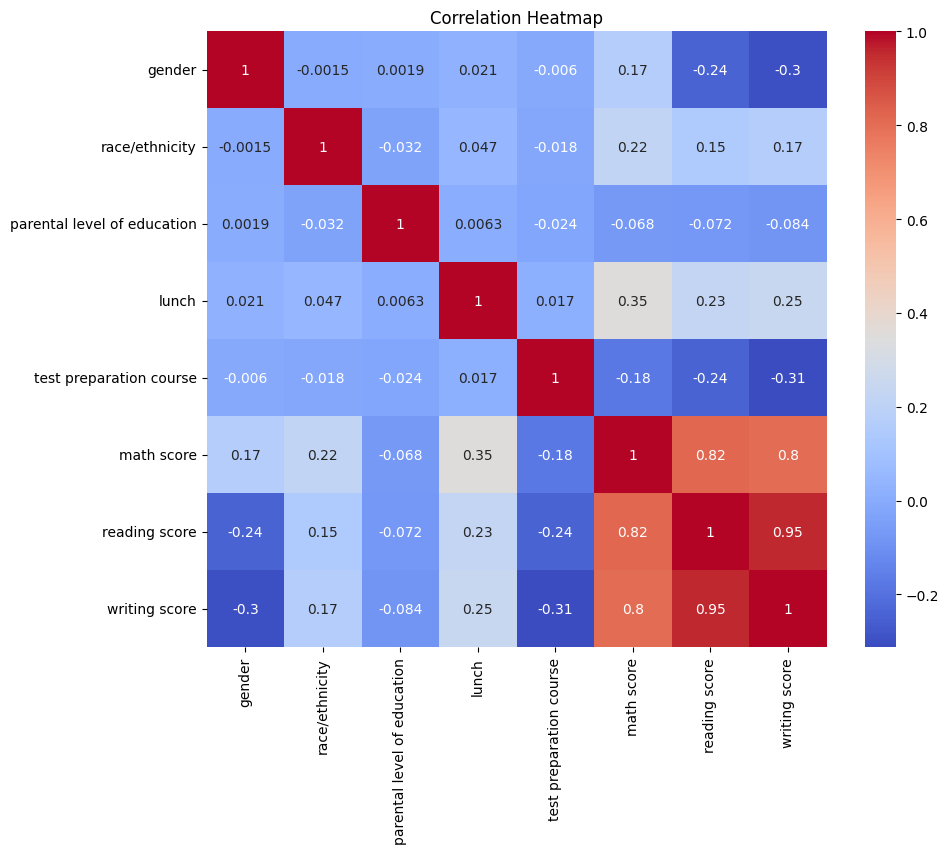

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Task 8: Select Features and Target Variable**

In [8]:
X = df.drop("math score", axis=1)

y = df["math score"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 7)
Target Shape: (1000,)


**Task 9: Split Dataset into Training and Testing Data**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 7)
Testing Data: (200, 7)


**Task 10: Build Random Forest Regression Model**

In [10]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


**Task 11: Make Predictions**

In [11]:
y_pred = model.predict(X_test)

print("Predicted Scores:")
print(y_pred[:10])

Predicted Scores:
[77.76 54.74 76.16 77.11 80.96 85.79 65.46 54.42 73.7  53.03]


**Task 12: Evaluate the Model**

In [12]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")

print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R2 Score:", r2)

Model Evaluation
Mean Absolute Error (MAE): 4.70082380952381
Mean Squared Error (MSE): 36.79422162429139
Root Mean Squared Error (RMSE): 6.065824068029948
R2 Score: 0.8487940184356789


**Task 13: Visualize Actual vs Predicted Scores**

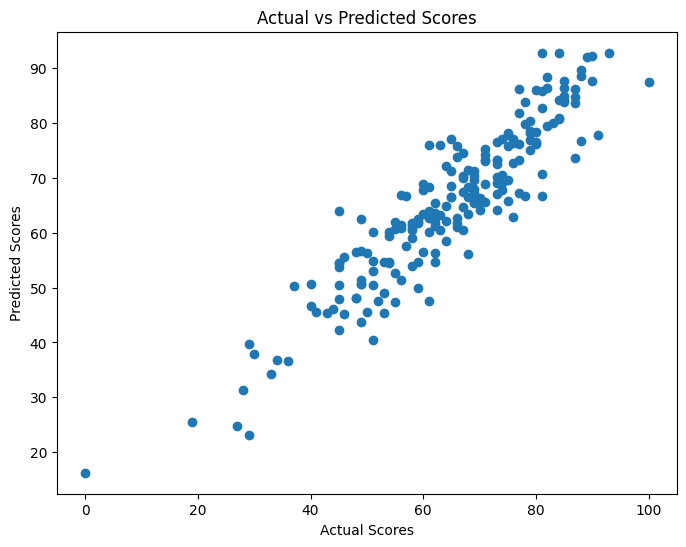

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Scores")

plt.ylabel("Predicted Scores")

plt.title("Actual vs Predicted Scores")

plt.show()

**Task 14: Display Feature Importance**

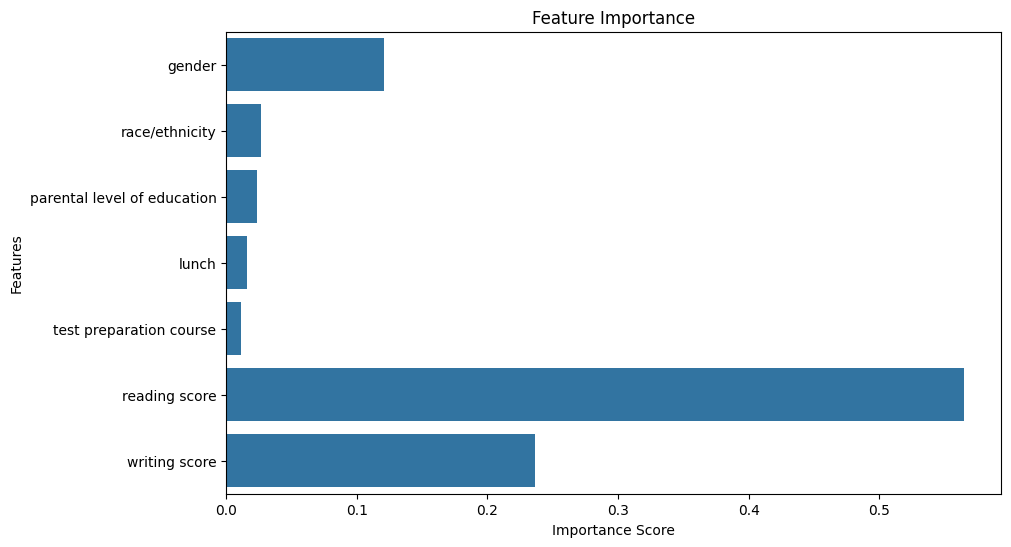

In [14]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

sns.barplot(x=importance, y=features)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

**Task 15: Conclusion**

In [15]:
print("Project Completed Successfully")
print("Random Forest Regressor was used to predict student math scores.")
print("The model was evaluated using MAE, MSE, RMSE, and R2 Score.")

Project Completed Successfully
Random Forest Regressor was used to predict student math scores.
The model was evaluated using MAE, MSE, RMSE, and R2 Score.
